In [7]:
import warnings
warnings.filterwarnings("ignore")

`Region` - Субъект РФ

`Wages` - Среднемесячная номинальная начисленная заработная плата работников организаций в 2021 году, руб.

`HighEdu` - Удельный вес занятого населения с высшим образованием в 2021 году, %

`SecEdu` - Удельный вес занятого населения со средним профессиональным образованием в 2021 году, %

`SecStudent` - Численность студентов, обучающихся по программам подготовки специалистов среднего звена на 10000 человек населения, 2021-2022 год обучения

`HighStudent` - Численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры на 10000 человек населения, 2021-2022 год обучения

`University` - Число организаций и филиалов организаций высшего образования в 2021 году

`Popul` - Среднегодовая численность населения в 2021 году, тыс. чел.

`WorkAge` - Численность населения в трудоспособном возрасте в 2021 году, тыс. чел.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy import stats
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier

In [11]:
df = pd.read_excel("dataReg.xlsx")

In [14]:
df

,Region,Wages,HighEdu,SecEdu,SecStudent,HighStudent,University,Popul,WorkAge
0,Алтайский край,33872,27.8,46.2,185,225,17,2282.3,1262.11
1,Амурская область,59098,27.4,48.3,238,185,6,777.2,455.44
2,Архангельская область,57979,27.3,56.4,179,161,7,1076.2,603.75
3,Астраханская область,42096,35.3,45.0,251,287,13,993.6,558.40
4,Белгородская область,41775,33.7,49.8,206,304,11,1536.6,874.33
...,...,...,...,...,...,...,...,...,...
80,Чеченская Республика,31291,39.2,32.6,183,222,4,1507.2,866.64
81,Чувашская Республика,35799,31.8,45.2,214,287,10,1203.2,681.01
82,Чукотский автономный округ,130738,36.5,54.8,140,19,1,49.8,31.87
83,Ямало-Ненецкий автономный округ,116376,44.9,40.3,153,4,1,549.6,353.94


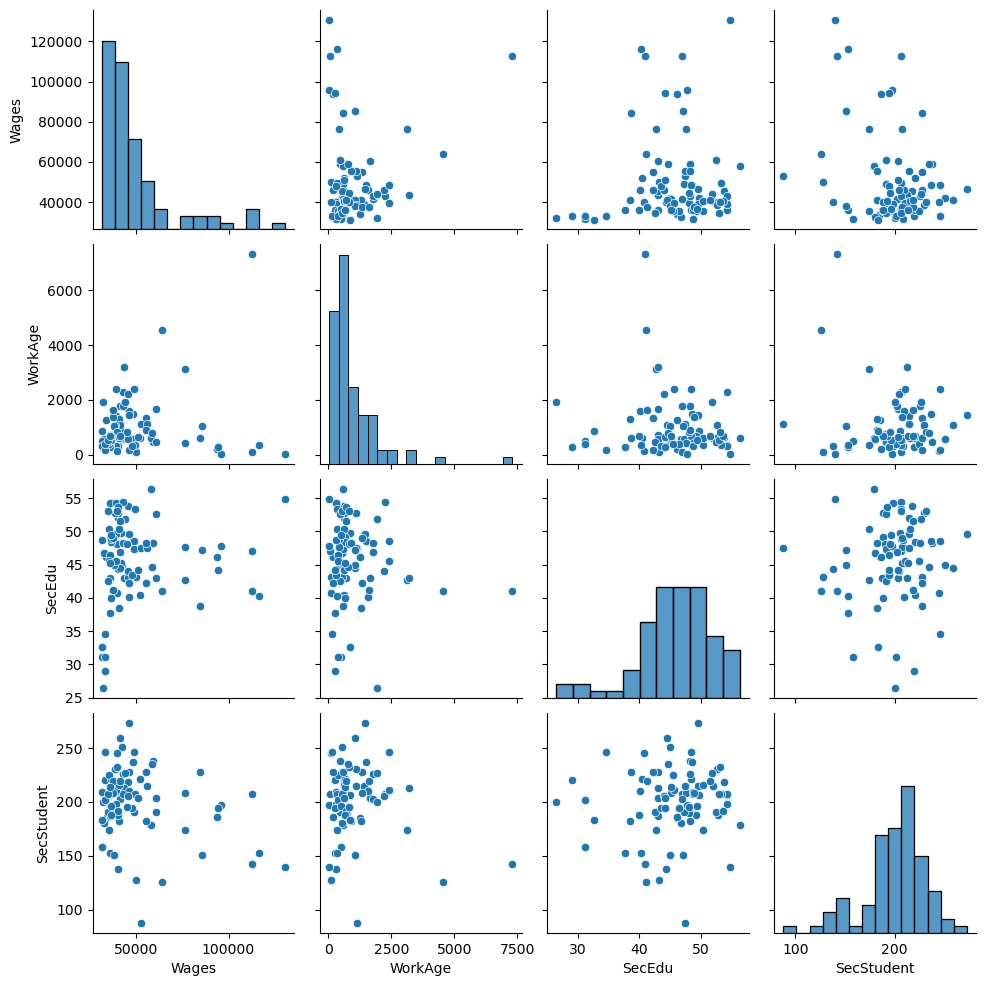

In [16]:
sns.pairplot(df[["Wages", "WorkAge", "SecEdu", "SecStudent"]])
plt.show()

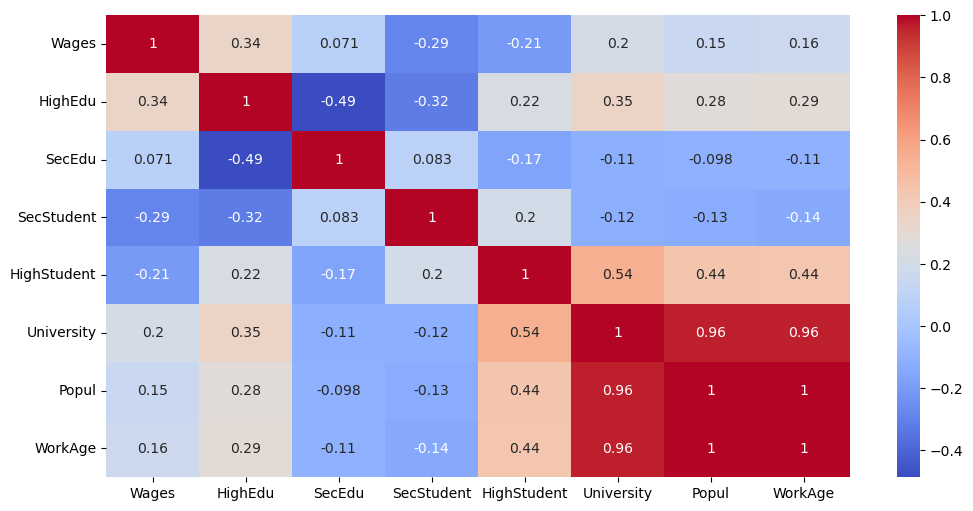

In [68]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [18]:
df[["Wages", "WorkAge", "SecEdu", "SecStudent"]].corr(numeric_only=True)

,Wages,WorkAge,SecEdu,SecStudent
Wages,1.000000,0.158958,0.071491,-0.285000
WorkAge,0.158958,1.000000,-0.109048,-0.138494
SecEdu,0.071491,-0.109048,1.000000,0.082926
SecStudent,-0.285000,-0.138494,0.082926,1.000000


# Task 1

Можно ли утверждать, что численность студентов среднего образования статистически значимо зависит от следующих показателей:
Средней начисленной заработной платы; Численностью работоспособного населения; Удельный вес занятого населения со средним профессиональным образованием. Выбрать метод МО, позволяющий ответить на данный вопрос, оценить модель, обосновать ответ используя статистические показатели. Можно ли использовать показатель "численность населения"?

In [26]:
formula = "SecStudent ~ Wages + WorkAge + SecEdu"
model = smf.ols(formula, data=df).fit()

In [27]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             SecStudent   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     2.958
Date:                Sat, 28 Feb 2026   Prob (F-statistic):             0.0372
Time:                        17:46:00   Log-Likelihood:                -408.76
No. Observations:                  85   AIC:                             825.5
Df Residuals:                      81   BIC:                             835.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    201.0338     26.575      7.565      0.0

==============================================================================

**Используем регрессионный анализ для первого пункта задачи (OLS). С оценкой по p-values и F‑статистике.**

**Выдвигаем нашу гипотезу: численность студентов среднего образования статистически значимо зависит от следующих показателей:
Средней начисленной заработной платы; Численностью работоспособного населения; Удельный вес занятого населения со средним профессиональным образованием**

**Выделяем нулевую(H0) и альтернативную(H1) гипотезы:**
- H0: SecStudent не зависит от тройки признаков
- H1: SecStudent зависит хотя бы от одного из трех признаков


**После обучения модели видим, что для средней начисленной заработной платы p-values равняется `0.011`, для численности населения в трудоспособном возрасте в 2021 году, тыс. чел. p-values равняется `0.437` и для удельного веса занятого населения со средним профессиональным образованием в 2021 году, % p-values равняется `0.382`.**

*Из этого мы можем утверждать, что самый малый p-value (< 0,05) у Wages влияет. У остальных признаков p-value достаточно высок, чтобы отвергнуть нулевую гипотезу. А для признака Wages мы отвергаем нулевую и принимаем альтернативную*


**Модель в свою очередь, оценивая метрику R-squared - 0.099, плохо объясняет данные. Но все таки по показателю Prob (F-statistic) - 0.0372, модель статистически важна**

Можно ли использовать показатель "численность населения"?
SecStudent — это отношение числа студентов к населению (на 10 000 чел.). То есть SecStudent конструктивно зависит от Popul, Popul уже заложен в структуру SecStudent, поэтому его добавление избыточно по смыслу.

# Task 2

Можно ли утверждать, что  города федерального значения отличаются от других регионов РФ?. Выбрать метод МО, позволяющий ответить на данный вопрос, оценить, обосновать ответ . 

In [678]:
avg_federal = df[df["Region"].isin(["г. Москва", "г. Санкт-Петербург", "г. Севастополь"])].describe().loc['mean'].round(1)
avg_region = df[~df["Region"].isin(["г. Москва", "г. Санкт-Петербург", "г. Севастополь"])].describe().loc['mean'].round(1)
moscow = df[df["Region"] == "г. Москва"].iloc[0]

df_vs = pd.DataFrame({"Mean_Federal": avg_federal, "Mean_Region": avg_region, "GAP": avg_federal - avg_region, "Moscow": moscow.iloc[1:]})

In [680]:
df_vs

,Mean_Federal,Mean_Region,GAP,Moscow
Wages,76390.7,48664.6,27726.1,112768
HighEdu,46.1,32.3,13.8,51.8
SecEdu,42.7,45.9,-3.2,41.0
SecStudent,151.3,202.2,-50.9,142
HighStudent,485.3,219.9,265.4,601
University,73.0,12.4,60.6,146
Popul,6180.7,1552.7,4628.0,12645.3
WorkAge,3575.5,886.3,2689.2,7308.98


### Снижение размерности

In [243]:
X_std = sc.fit_transform(df.iloc[:, 1:])

In [245]:
target = np.zeros(85)
target[10] = 1 # г. Москва
target[11] = 2 # г. Санкт-Петербург
target[12] = 3 # г. Севастополь
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [706]:
tsne = TSNE(n_components=2, perplexity=23, learning_rate=10)
Tmatrix = tsne.fit_transform(X_std)
dfT = pd.DataFrame(Tmatrix)

<Axes: xlabel='0', ylabel='1'>

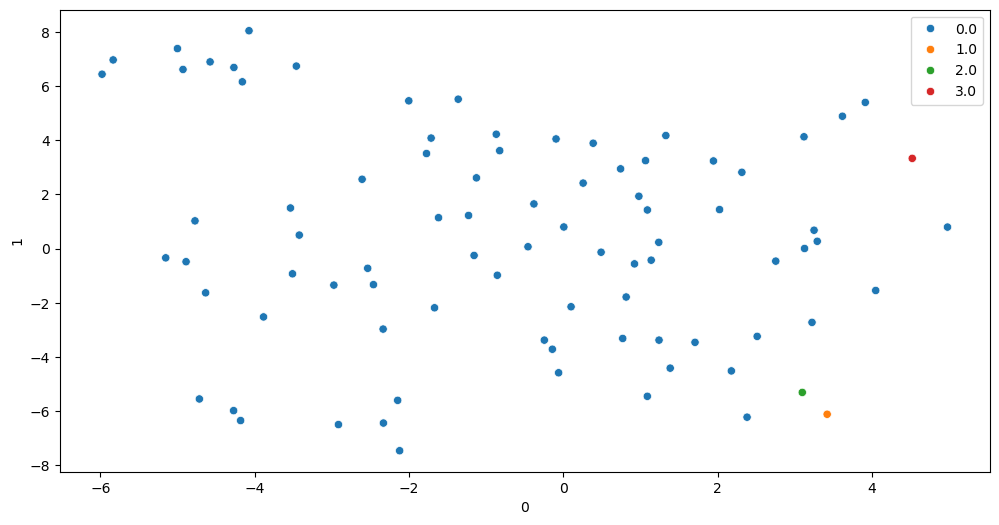

In [707]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=dfT[0], y=dfT[1], hue=target, palette='tab10')

При нелинейном понижении размерности(t-SNE) наших данных, мы можем визуализировать следующую картину: Мы видим, что Москва(оранжевый маркер) и Санкт-Петербург(зеленый маркер) находятся относительно около друг друга. При это на взгляд эти города не образуют отдельный кластер, в должны входить в уже имеющийся(пример рисунка ниже). Севастополь(красный маркер) при этом отдален от двух других городов, но он имеет похожие на себя точки рядом.

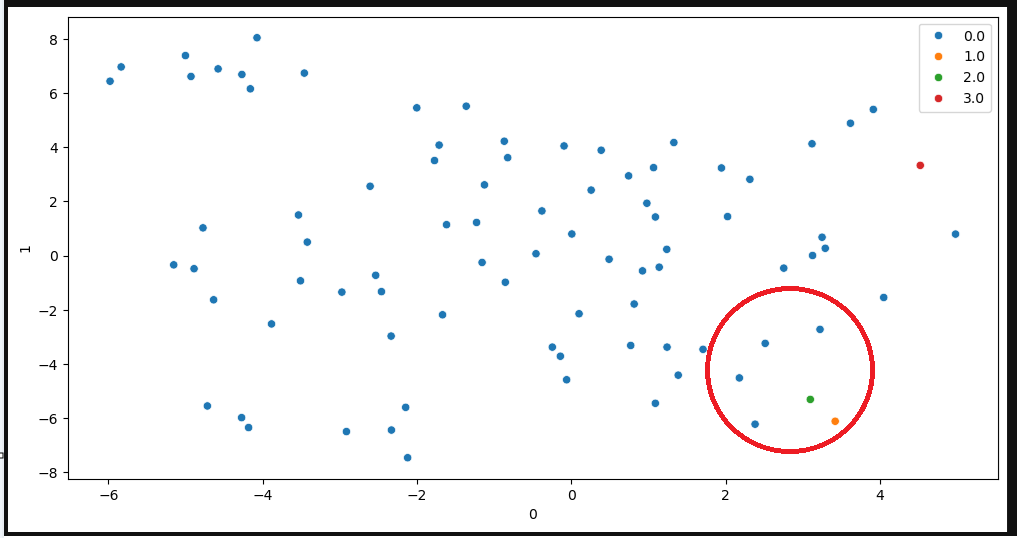

Обобщая, мы можем сказать, что города ФЗ не сильно отклоняются от других точек. И находятся рядом

### Кластеризация

#### Кластеризация K-средних

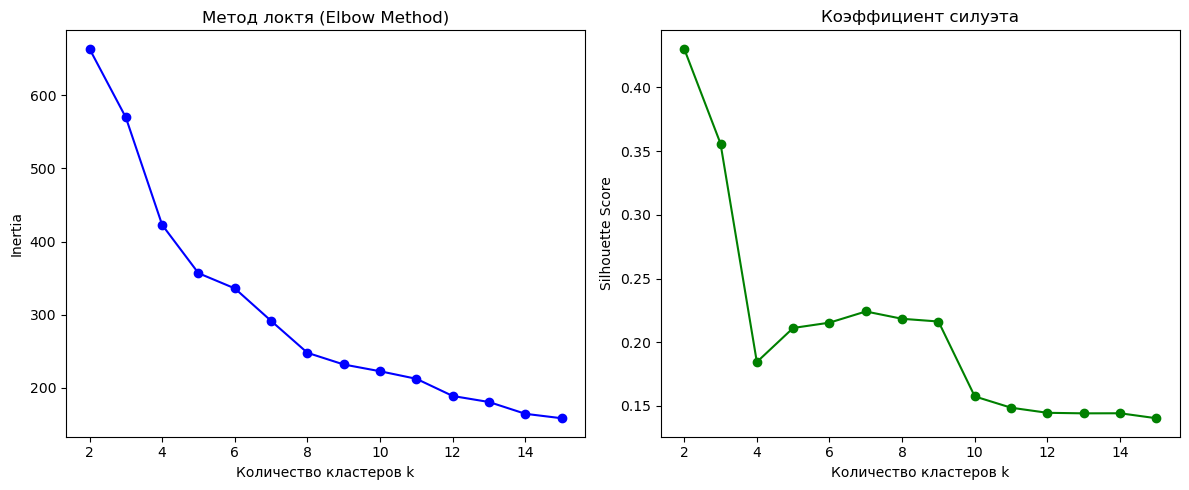

In [532]:
class_df = X_std

inertias = []
silhouettes = []

K = range(2, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(class_df)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(class_df, kmeans.labels_))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K, inertias, 'bo-')
plt.xlabel('Количество кластеров k')
plt.ylabel('Inertia')
plt.title('Метод локтя (Elbow Method)')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'go-')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette Score')
plt.title('Коэффициент силуэта')
plt.tight_layout()
plt.show()

In [534]:
kmeans_best = KMeans(n_clusters=3, random_state=42)
kmeans_best.fit(X_std)

KMeans(n_clusters=3, random_state=42)

In [536]:
clusters = kmeans_best.labels_

In [538]:
np.bincount(clusters)

array([ 9, 62, 14], dtype=int64)

In [544]:
clusters[10], clusters[11], clusters[12]

(2, 2, 2)

Используем алгоритм k-средних для кластеризации. По методу локтя видим, что оптимальны 3 кластера. Обучим модель и проверим. После обучения видим, что все города ФЗ попали в один кластер - 2, численностью 62 точки.
K-средних отнес ФЗ города к обычным регионам, что означает, что они схожи.

In [548]:
kmeans_best2 = KMeans(n_clusters=7, random_state=42)
kmeans_best2.fit(X_std)

KMeans(n_clusters=7, random_state=42)

In [550]:
clusters2 = kmeans_best2.labels_

In [554]:
np.bincount(clusters2)

array([ 8, 19, 11, 34, 10,  1,  2], dtype=int64)

In [560]:
clusters2[10], clusters[11], clusters[12]

(5, 2, 2)

Попробуем выбрать чуть большее количество кластеров - 7. Являющимся не лучшим, но вторым по метрикам. После обучения видим, что Санкт-Петербург и Севастополь относятся к одному кластеру - 2, численностью 19 точек.
Но вот москва образует собственный кластер. И находится одна в этом кластере.

#### Кластеризация DBScan

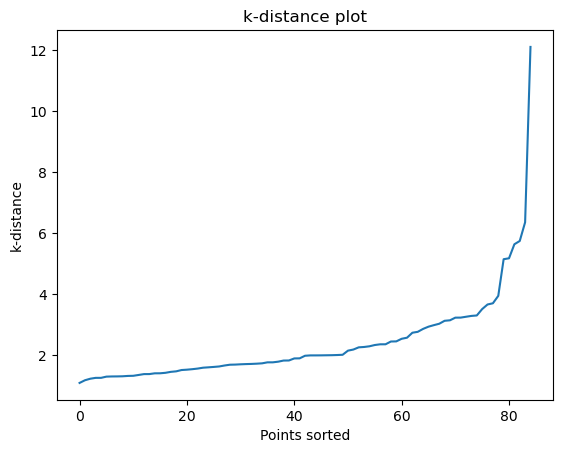

In [603]:
k = 10
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_std)

distances, _ = nn.kneighbors(X_std)

k_dist = np.sort(distances[:, k-1])

plt.plot(k_dist)
plt.ylabel("k-distance")
plt.xlabel("Points sorted")
plt.title("k-distance plot")
plt.show()

In [613]:
dbscan = DBSCAN(eps=6, min_samples=4)
clusters_dbs = dbscan.fit_predict(X_std)

In [615]:
ser = pd.Series(clusters_dbs)
ser.value_counts()

 0    84
-1     1
Name: count, dtype: int64

In [619]:
clusters_dbs[10]

-1

Пробуем использовать еще один метод кластеризации - dbscan. После обучения видно, что Москва снова отделяется от всех регионов, а другие города и регионы образуют один кластер. 

**Обобщая:**

Можно утверждать, что города федерального значения в целом не сильно отличаются от других регионов РФ, так как при нелинейной понижении размерности их точки не формируют отдельный, чётко выделенный кластер, а располагаются рядом с другими регионами.

При использовании алгоритма k‑means (оптимально 3 кластера) все города ФЗ попали в один и тот же кластер, что означает их схожесть с остальными регионами по данным признакам. При увеличении числа кластеров до 7 кластер с Москвой становится отдельным, тогда как Санкт‑Петербург и Севастополь остаются в общем кластере, что говорит о частичном отличии Москвы.

При использовании DBSCAN Москва также отделяется в отдельный компонент, тогда как остальные регионы и другие города ФЗ остаются в одном кластере.

Таким образом, города ФЗ не образуют принципиально отдельную группу, но Москва в ряде сценариев выделяется как аномалия, что указывает на её частичную отличимость от других регионов.